#  Machine Learning Lab Demo
## KNN | Overfitting & Underfitting | Confusion Matrix | ROC Curve

---

---

##  Step 0: Import All Required Libraries

Before we do anything, we import all the tools (libraries) we need.
Think of this like opening your toolbox before starting work.

In [1]:
# --- Core Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sklearn: Machine Learning Tools ---
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# --- Make plots look nice ---
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

print(" All libraries imported successfully!")

 All libraries imported successfully!


---
##  Step 1: Load and Explore the Dataset

We will use the **Breast Cancer Dataset** a classic dataset in ML.

- It has **30 features** (measurements from a tumor scan)
- The **target (label)** is: **0 = Malignant (cancerous)**, **1 = Benign (not cancerous)**
- Our job: Train a model that predicts whether a tumor is cancerous or not.

In [2]:
# Load the dataset
data = load_breast_cancer()

# Convert to a DataFrame so we can see it like a table
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(" Shape of dataset:", df.shape)
print("\n First 5 rows:")
df.head()

 Shape of dataset: (569, 31)

 First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Class Distribution:
target
1    357
0    212
Name: count, dtype: int64

  0 = Malignant (Cancerous)
  1 = Benign (Not Cancerous)


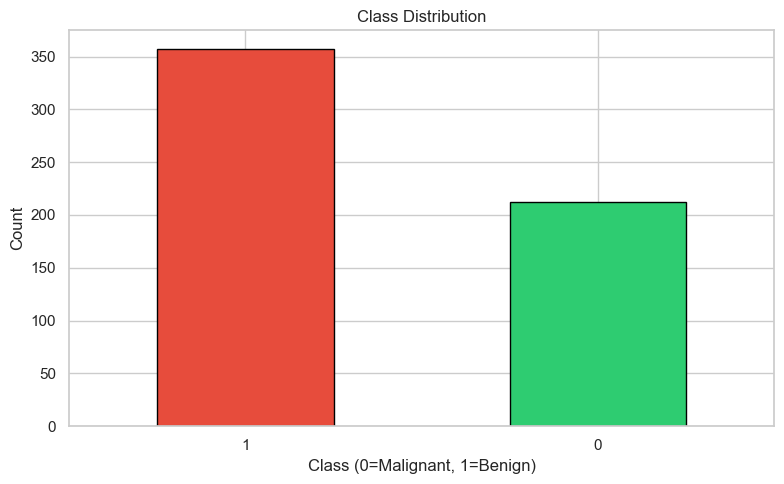

In [3]:
# Check how many samples are in each class
print("Class Distribution:")
print(df['target'].value_counts())
print("\n  0 = Malignant (Cancerous)")
print("  1 = Benign (Not Cancerous)")

# Visualize it
df['target'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Class (0=Malignant, 1=Benign)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Step 2: Split the Data into Train & Test Sets

We split data into two parts:
- **Training set (80%)** → Model *learns* from this
- **Testing set (20%)** → We *evaluate* the model on this (unseen data)

Think of it like: **Study from a textbook (train), then give an exam (test)**.

In [4]:
# Features (X) and Labels (y)
X = data.data
y = data.target

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 455
Testing  samples : 114


### Feature Scaling (Normalization)

KNN uses **distance** to find nearest neighbors. If features have very different scales (e.g., one feature is 0.001 and another is 1000), KNN will get confused.

**StandardScaler** fixes this by making all features have:
- Mean = 0
- Standard Deviation = 1

In [5]:
scaler = StandardScaler()

# Fit on train, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(" Feature scaling done!")
print(f"   Before scaling - Mean of feature 0: {X_train[:, 0].mean():.2f}")
print(f"   After  scaling - Mean of feature 0: {X_train_scaled[:, 0].mean():.4f}")

 Feature scaling done!
   Before scaling - Mean of feature 0: 14.12
   After  scaling - Mean of feature 0: -0.0000


---
##  Step 3: KNN — K-Nearest Neighbors

###  What is KNN?

> **"Tell me who your neighbors are, and I'll tell you who you are."**

KNN is a simple algorithm:
1. Take a new data point
2. Find the **K closest points** in the training data (using distance)
3. **Vote** — whichever class appears most among the K neighbors wins

###  What is K?
- K = number of neighbors to look at
- **Small K** (e.g., K=1) → Very sensitive, can overfit
- **Large K** (e.g., K=50) → Too general, can underfit
- We need to find the **right K!**

In [6]:
# Train a basic KNN model with K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = knn.predict(X_test_scaled)

print(" KNN model trained with K=5")
print(f"\n Accuracy on Test Set: {accuracy_score(y_test, y_pred)*100:.2f}%")

 KNN model trained with K=5

 Accuracy on Test Set: 94.74%


###  Finding the Best K

Let's try different values of K and see which gives the best accuracy on the test set.

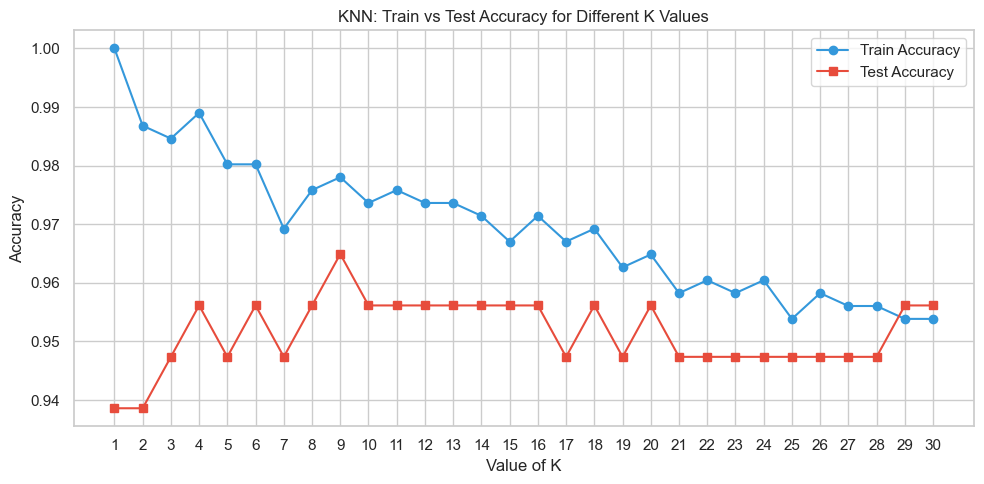


 Best K = 9 with Test Accuracy = 96.49%


In [7]:
train_accuracies = []
test_accuracies  = []
k_values = range(1, 31)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    train_accuracies.append(model.score(X_train_scaled, y_train))
    test_accuracies.append(model.score(X_test_scaled, y_test))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o', color='#3498db')
plt.plot(k_values, test_accuracies,  label='Test Accuracy',  marker='s', color='#e74c3c')
plt.xlabel('Value of K')
plt.ylabel('Accuracy')
plt.title('KNN: Train vs Test Accuracy for Different K Values')
plt.legend()
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(test_accuracies)]
print(f"\n Best K = {best_k} with Test Accuracy = {max(test_accuracies)*100:.2f}%")

---
## Step 4: Underfitting, Overfitting & Generalization

###  Simple Explanation:

| Concept | What it means | KNN Example |
|---|---|---|
| **Underfitting** | Model is too simple — doesn't even learn training data well | Very large K (e.g., K=50) |
| **Overfitting** | Model memorizes training data — fails on new data | Very small K (e.g., K=1) |
| **Generalization** | Model learns the pattern, works well on new data | Just right K |

>  Think of studying for an exam:
> - **Underfitting** = Didn't study at all
> - **Overfitting** = Memorized every word but can't apply concepts
> - **Generalized** = Understood concepts, can answer any question

In [8]:
print(" Demonstrating Underfitting vs Overfitting vs Generalized:\n")
print(f"{'K Value':<12} {'Train Acc':<14} {'Test Acc':<14} {'Condition'}")
print("-" * 55)

for k, condition in [(1, 'Overfitting'), (best_k, 'Generalized '), (50, 'Underfitting')]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    tr_acc = model.score(X_train_scaled, y_train)
    te_acc = model.score(X_test_scaled, y_test)
    print(f"K = {k:<8} {tr_acc*100:<14.2f} {te_acc*100:<14.2f} {condition}")

 Demonstrating Underfitting vs Overfitting vs Generalized:

K Value      Train Acc      Test Acc       Condition
-------------------------------------------------------
K = 1        100.00         93.86          Overfitting
K = 9        97.80          96.49          Generalized 
K = 50       95.16          95.61          Underfitting


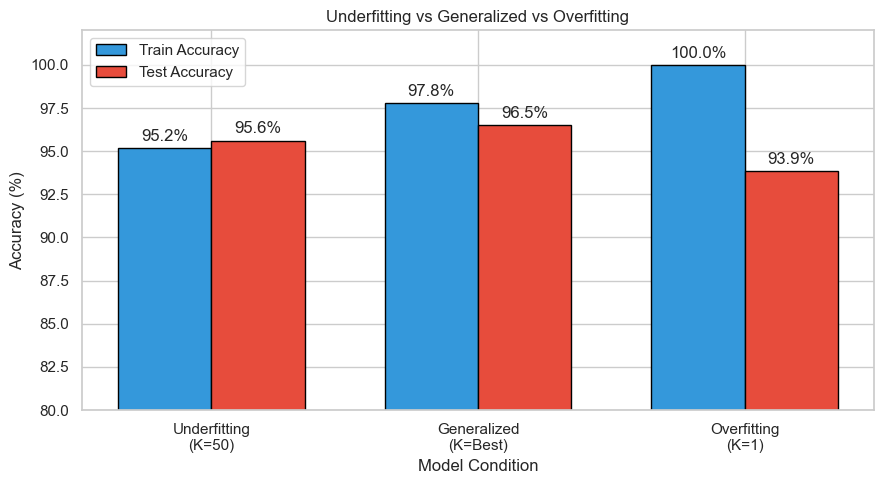

In [9]:
# Visual summary
categories = ['Underfitting\n(K=50)', 'Generalized\n(K=Best)', 'Overfitting\n(K=1)']
train_acc_vals = []
test_acc_vals  = []

for k in [50, best_k, 1]:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    train_acc_vals.append(m.score(X_train_scaled, y_train))
    test_acc_vals.append(m.score(X_test_scaled, y_test))

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, [v*100 for v in train_acc_vals], width, label='Train Accuracy', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, [v*100 for v in test_acc_vals],  width, label='Test Accuracy',  color='#e74c3c', edgecolor='black')

ax.set_xlabel('Model Condition')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Underfitting vs Generalized vs Overfitting')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(80, 102)
ax.legend()
ax.bar_label(bars1, fmt='%.1f%%', padding=3)
ax.bar_label(bars2, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

---
##  Step 5: Confusion Matrix

###  What is a Confusion Matrix?

It shows us **where the model got confused** — which predictions were right and which were wrong.

```
                    Predicted: 0      Predicted: 1
Actual: 0    |   TN (True Neg)  |  FP (False Pos) |
Actual: 1    |   FN (False Neg) |  TP (True Pos)  |
```

| Term | Meaning | Example (Cancer) |
|------|---------|------------------|
| **TP** True Positive  | Predicted Positive, Actually Positive | Predicted cancer → Has cancer  |
| **TN** True Negative  | Predicted Negative, Actually Negative | Predicted no cancer → No cancer  |
| **FP** False Positive | Predicted Positive, Actually Negative | Predicted cancer → No cancer  |
| **FN** False Negative | Predicted Negative, Actually Positive | Predicted no cancer → Has cancer  |

In [10]:
# Use the best K model
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_pred_best = best_knn.predict(X_test_scaled)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Extract TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()
print(f"True Positives  (TP): {TP}")
print(f"True Negatives  (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")

True Positives  (TP): 69
True Negatives  (TN): 41
False Positives (FP): 2
False Negatives (FN): 2


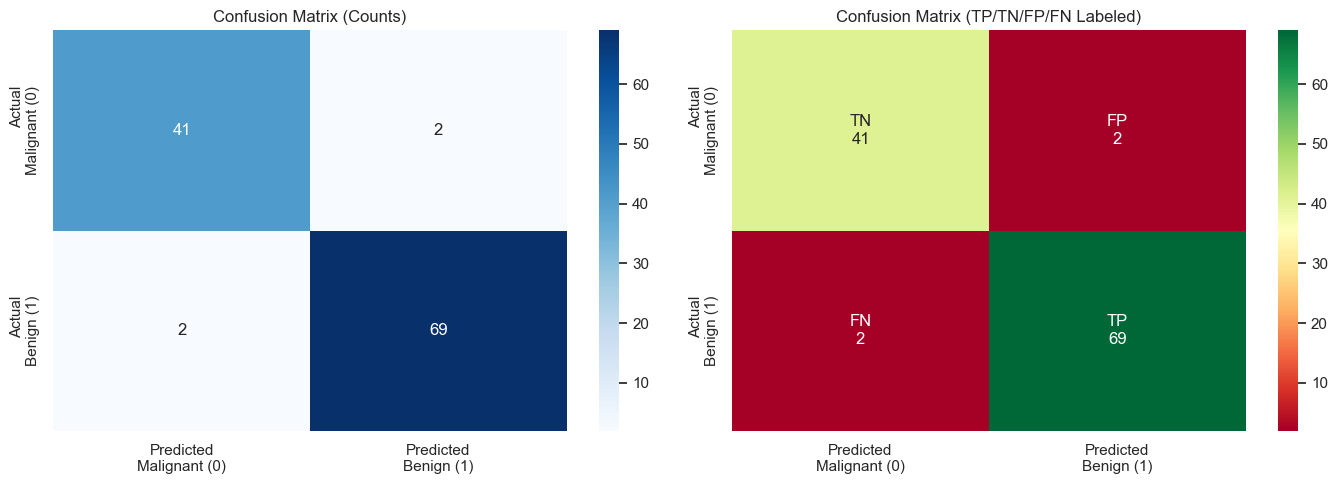

In [11]:
# Visualize the Confusion Matrix as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Counts ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted\nMalignant (0)', 'Predicted\nBenign (1)'],
            yticklabels=['Actual\nMalignant (0)', 'Actual\nBenign (1)'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')

# --- Plot 2: Labeled TP/TN/FP/FN ---
labels = np.array([[f'TN\n{TN}', f'FP\n{FP}'],
                   [f'FN\n{FN}', f'TP\n{TP}']])
colors = np.array([[TN, 0], [0, TP]])
sns.heatmap(cm, annot=labels, fmt='', cmap='RdYlGn',
            xticklabels=['Predicted\nMalignant (0)', 'Predicted\nBenign (1)'],
            yticklabels=['Actual\nMalignant (0)', 'Actual\nBenign (1)'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (TP/TN/FP/FN Labeled)')

plt.tight_layout()
plt.show()

---
##  Step 6: Accuracy, Precision, Recall & F1-Score

###  Formulas Made Simple:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

> "Out of all predictions, how many were correct?"

$$\text{Precision} = \frac{TP}{TP + FP}$$

> "When we predicted Positive, how often were we right?"

$$\text{Recall} = \frac{TP}{TP + FN}$$

> "Out of all actual Positives, how many did we catch?"

$$\text{F1 Score} = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

> "Balance between Precision and Recall — a single combined score."

---
###  Real-World Intuition (Cancer Example):
- **High Recall** is critical → We don't want to miss any cancer patient (FN is dangerous!)
- **High Precision** → We don't want to scare healthy people (FP causes stress)
- **F1-Score** → Balances both

In [12]:
# Calculate each metric manually to understand them
accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * (precision * recall) / (precision + recall)

print(" Manually Calculated Metrics:")
print(f"   Accuracy  = ({TP} + {TN}) / ({TP}+{TN}+{FP}+{FN}) = {accuracy*100:.2f}%")
print(f"   Precision = {TP} / ({TP}+{FP})                      = {precision*100:.2f}%")
print(f"   Recall    = {TP} / ({TP}+{FN})                      = {recall*100:.2f}%")
print(f"   F1 Score  = 2 * ({precision:.3f} * {recall:.3f}) / ({precision:.3f}+{recall:.3f}) = {f1*100:.2f}%")

print("\n Verified using sklearn:")
print(f"   Accuracy  : {accuracy_score(y_test, y_pred_best)*100:.2f}%")
print(f"   Precision : {precision_score(y_test, y_pred_best)*100:.2f}%")
print(f"   Recall    : {recall_score(y_test, y_pred_best)*100:.2f}%")
print(f"   F1 Score  : {f1_score(y_test, y_pred_best)*100:.2f}%")

 Manually Calculated Metrics:
   Accuracy  = (69 + 41) / (69+41+2+2) = 96.49%
   Precision = 69 / (69+2)                      = 97.18%
   Recall    = 69 / (69+2)                      = 97.18%
   F1 Score  = 2 * (0.972 * 0.972) / (0.972+0.972) = 97.18%

 Verified using sklearn:
   Accuracy  : 96.49%
   Precision : 97.18%
   Recall    : 97.18%
   F1 Score  : 97.18%


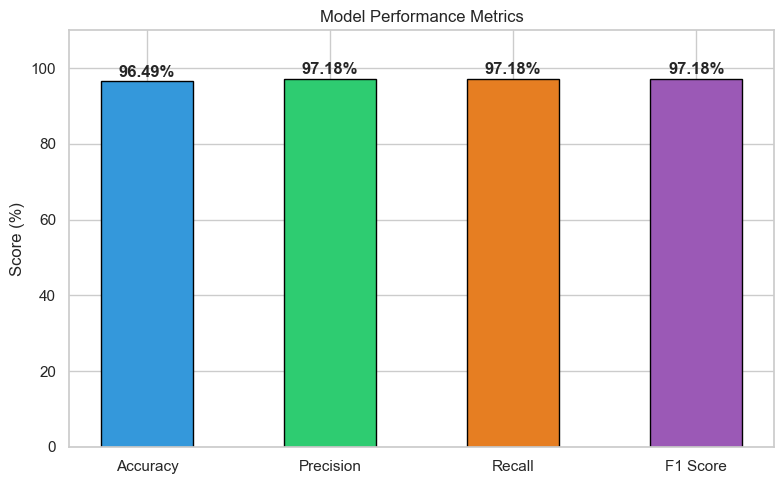


 Full Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.95      0.95        43
      Benign       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [13]:
# Visualize all metrics in a bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [
    accuracy_score(y_test, y_pred_best),
    precision_score(y_test, y_pred_best),
    recall_score(y_test, y_pred_best),
    f1_score(y_test, y_pred_best)
]

colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
bars = plt.bar(metrics, [v*100 for v in values], color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 110)
plt.ylabel('Score (%)')
plt.title('Model Performance Metrics')
plt.tight_layout()
plt.show()

# Full classification report
print("\n Full Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Malignant', 'Benign']))

---
## Step 7: ROC Curve & AUC Score

###  What is the ROC Curve?

ROC = **Receiver Operating Characteristic**

It answers: *"How well can my model tell apart the two classes?"*

- **X-axis**: False Positive Rate (FPR) → How often we cry wolf
- **Y-axis**: True Positive Rate (TPR / Recall) → How many positives we catch

###  What is AUC?
AUC = **Area Under the Curve**
- **AUC = 1.0** → Perfect model 
- **AUC = 0.5** → Random guessing (useless) 
- **AUC > 0.9** → Excellent 

>  The closer the ROC curve hugs the **top-left corner**, the better the model!

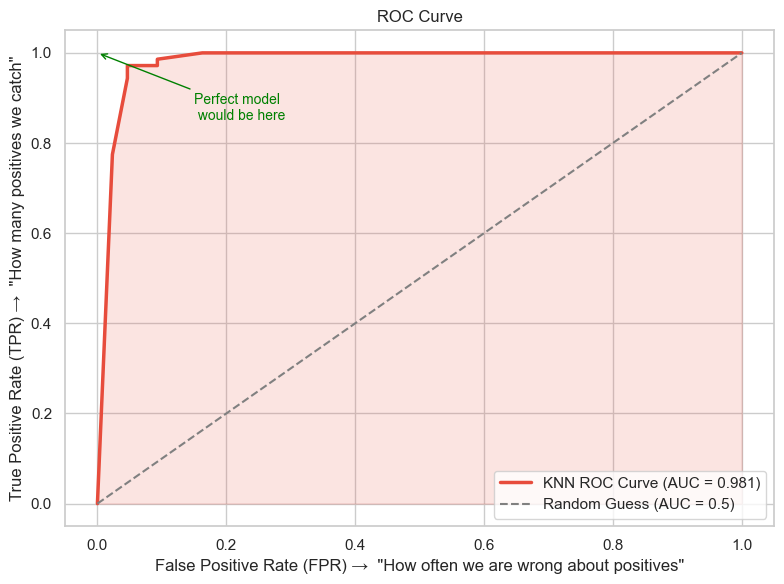


🏆 AUC Score: 0.9807
   → Excellent model!


In [14]:
# Get probability predictions (needed for ROC curve)
y_prob = best_knn.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1 (Benign)

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'KNN ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Guess (AUC = 0.5)')

plt.fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')

plt.xlabel('False Positive Rate (FPR) →  "How often we are wrong about positives"')
plt.ylabel('True Positive Rate (TPR) →  "How many positives we catch"')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.annotate('Perfect model\n would be here', xy=(0, 1), xytext=(0.15, 0.85),
             arrowprops=dict(arrowstyle='->', color='green'), color='green', fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n🏆 AUC Score: {auc_score:.4f}")
if auc_score >= 0.9:
    print("   → Excellent model!")
elif auc_score >= 0.8:
    print("   → Good model!")
else:
    print("   → Needs improvement.")

###  Comparing Multiple K Values on ROC Curve

Let's see how the ROC curve changes for different K values — this nicely shows overfitting vs underfitting.

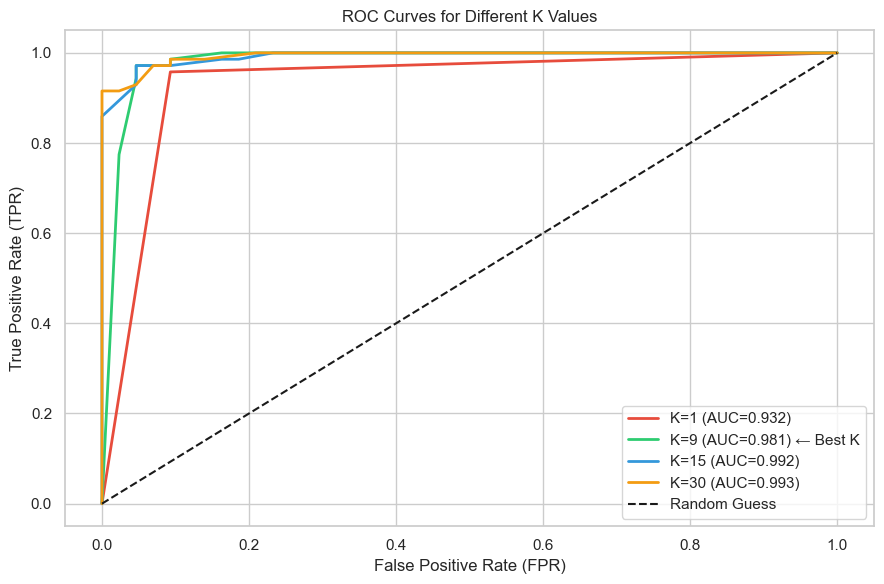

In [15]:
plt.figure(figsize=(9, 6))

k_compare = [1, best_k, 15, 30]
colors_roc = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

for k, color in zip(k_compare, colors_roc):
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    probs = m.predict_proba(X_test_scaled)[:, 1]
    fpr_k, tpr_k, _ = roc_curve(y_test, probs)
    auc_k = roc_auc_score(y_test, probs)
    label = f'K={k} (AUC={auc_k:.3f})'
    if k == best_k:
        label += ' ← Best K'
    plt.plot(fpr_k, tpr_k, color=color, lw=2, label=label)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curves for Different K Values')
plt.legend()
plt.tight_layout()
plt.show()

---
## Step 8: Complete Summary

Let's put everything together in one final summary.

In [16]:
print("=" * 55)
print("        FINAL SUMMARY OF OUR MODEL")
print("=" * 55)
print(f"  Dataset         : Breast Cancer (569 samples)")
print(f"  Algorithm       : K-Nearest Neighbors (KNN)")
print(f"  Best K Found    : {best_k}")
print("-" * 55)
print(f"  Accuracy        : {accuracy_score(y_test, y_pred_best)*100:.2f}%")
print(f"  Precision       : {precision_score(y_test, y_pred_best)*100:.2f}%")
print(f"  Recall          : {recall_score(y_test, y_pred_best)*100:.2f}%")
print(f"  F1 Score        : {f1_score(y_test, y_pred_best)*100:.2f}%")
print(f"  AUC Score       : {auc_score:.4f}")
print("-" * 55)
print(f"  True Positives  : {TP}")
print(f"  True Negatives  : {TN}")
print(f"  False Positives : {FP}")
print(f"  False Negatives : {FN}")
print("=" * 55)

        FINAL SUMMARY OF OUR MODEL
  Dataset         : Breast Cancer (569 samples)
  Algorithm       : K-Nearest Neighbors (KNN)
  Best K Found    : 9
-------------------------------------------------------
  Accuracy        : 96.49%
  Precision       : 97.18%
  Recall          : 97.18%
  F1 Score        : 97.18%
  AUC Score       : 0.9807
-------------------------------------------------------
  True Positives  : 69
  True Negatives  : 41
  False Positives : 2
  False Negatives : 2


---
##  Concept Recap Card

| Concept | One-Line Summary |
|---|---|
| **KNN** | Classify based on K nearest neighbors (majority vote) |
| **Overfitting** | Model memorizes training data, fails on new data (small K) |
| **Underfitting** | Model too simple, can't even learn training data (large K) |
| **Generalization** | Model learns the pattern and works well on new data |
| **Confusion Matrix** | Table showing TP, TN, FP, FN |
| **Accuracy** | (TP+TN) / Total — overall correctness |
| **Precision** | TP / (TP+FP) — quality of positive predictions |
| **Recall** | TP / (TP+FN) — coverage of actual positives |
| **F1 Score** | Harmonic mean of Precision and Recall |
| **ROC Curve** | Visual of TPR vs FPR at different thresholds |
| **AUC** | Area under ROC curve — higher = better (max = 1.0) |

---

>  **Good luck with your lab!** Try changing the value of K, or the test_size in Step 2, and observe how the metrics change!
